# Combinatorial Optimization

## Introduction  

In this notebook you will see implementtions of different heuristics for the **Traveling Salesperson Problem (TSP)** ([Wikipedia link](https://en.wikipedia.org/wiki/Travelling_salesman_problem)).  

### Task
Given a graph, our goal is to construct the shortest **Hamiltonian cycle** (a tour that visits each node exactly once and returns to the start). Finding the *optimal* tour is computationally expensive, so we will focus on approximating high-quality solutions efficiently.  

### Problem Setup  
- **Graph definition**: We consider a **complete (fully connected) graph** where nodes are points sampled uniformly from the unit square [0,1]².  
- **Edge weights**: The weight of an edge between two nodes is the **Euclidean distance** between their coordinates.  
- **Tour representation**: For convenience, a tour can be represented either as:  
  - An **ordered list of nodes** (e.g., [$v_0$, $v_1$, ..., $v_n$, $v_0$]), or  
  - An **ordered list of edges** (e.g., [($v_0$, $v_1$), ($v_1$, $v_2$), ..., ($v_n$, $v_0$)]).  

### Plan

1. Algorithmic heuristics
2. Greedy heurstic with GNN
3. Autoregressive model

In [ ]:
Tfrom typing import List, Tuple, Callable, Optional
import math

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

import tqdm

import torch

from IPython.display import clear_output

In [ ]:
def sample_points(n_points: int) -> torch.Tensor:
    return torch.rand(n_points, 2)

def plot_points_with_edges(
    points: torch.Tensor,
    edges: Optional[List[Tuple[int, int]]] = None
) -> None:
    fig, ax = plt.subplots(figsize=(5, 5))

    ax.scatter(points[:, 0], points[:, 1], c='red', s=100, zorder=5)

    if edges:
        for i, (from_idx, to_idx) in enumerate(edges):
            start = points[from_idx]
            end = points[to_idx]

            if i == 0:
                ax.annotate('', xy=end, xytext=start,
                            arrowprops=dict(arrowstyle='->', color='blue',
                                          linewidth=2, shrinkA=10, shrinkB=10))
            else:
                ax.plot([start[0], end[0]], [start[1], end[1]],
                       'b-', linewidth=1, zorder=3)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

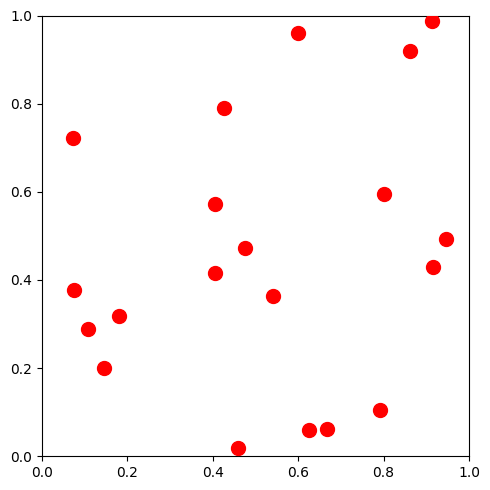

In [ ]:
n = 20
points = sample_points(n)
plot_points_with_edges(points)

## Part 1. Algorithmic heuristics

### Greedy heuristic

We begin with a simple **greedy heuristic** to construct a feasible TSP solution

In [ ]:
def distance(x, y):
    return math.sqrt((x[0] - y[0]) ** 2 + (x[1] - y[1]) ** 2)


def to_edges(tour: [int]):
    return [(tour[x - 1], tour[x]) for x in range(1, len(tour))]


def edges_score(points, edges):
    assert len(points) == len(edges)
    return sum(distance(points[x], points[y]) for x, y in edges)


def greedy_cost_heuristic(cost: torch.Tensor, starting_node: int = 0) -> list[tuple[int, int]]:
    """
    constructs a greedy TSP tour starting from given node, always choosing the lowest-cost available edge.
    """
    cost = cost.clone().detach()
    assert cost.ndim == 2 and cost.shape[0] == cost.shape[1]
    n = cost.shape[0]

    tour = [starting_node]
    used_nodes = torch.zeros(n, dtype=torch.bool)
    used_nodes[starting_node] = 1

    for _ in range(1, n):
        costs_from_current_node = cost[tour[-1]]
        costs_from_current_node[used_nodes] = torch.inf
        next_node = torch.argmin(costs_from_current_node)
        used_nodes[next_node] = 1
        tour.append(next_node)

    tour.append(starting_node)

    return to_edges(tour)

def distance_matrix(points: torch.Tensor) -> torch.Tensor:
    """
    compute pairwise Euclidean distances between points.
    """
    diff = points.unsqueeze(0) - points.unsqueeze(1)
    return torch.sqrt((diff.pow(2).sum(-1)))


def greedy_distance_heuristic(points: torch.Tensor, starting_node: int = 0) -> list[tuple[int, int]]:
    """
    constructs a greedy TSP tour based on Euclidean distances between points.
    """
    return greedy_cost_heuristic(distance_matrix(points), starting_node)

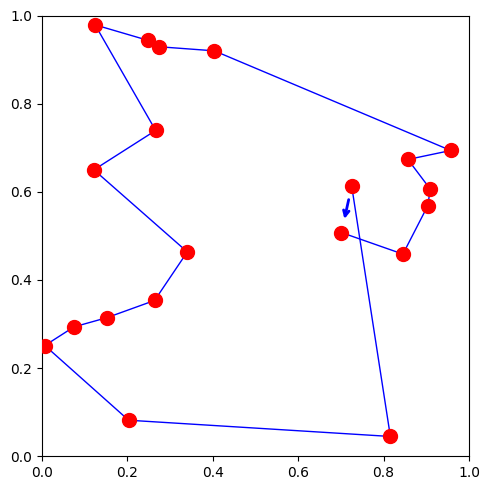

In [ ]:
points = sample_points(n)
tour = greedy_distance_heuristic(points)
plot_points_with_edges(points, tour)

### 2-opt Heuristic

Now, let's implement something more interesting: the **2-opt heuristic** ([Wikipedia](https://en.wikipedia.org/wiki/2-opt)).

2-opt is a local search heuristic, meaning it moves from solution to solution in the space of candidate solutions by applying local changes.

In short, a 2-opt step can be described as follows:
1. select two edges and their endpoints
2. swap the endpoints if the new tour is shorter  
   *(note: Not all swaps produce valid tours!)*

The selection of edges at each step can be done in several ways (e.g., choosing the first improving pair found or the best available improvement).

In [ ]:
def two_opt_tour_step(points: torch.Tensor, edges: list[list[int]]) -> tuple[list[list[int]], bool]:
    """
    performs a single step of 2-opt optimization for TSP tours.
    """
    if not edges:
        return edges, False

    #сonvert edges to tour representation
    tour = [edges[0][0]]
    for edge in edges:
        tour.append(edge[1])

    n = len(tour) - 1
    dist_matrix = distance_matrix(points)

    #large n, random sampling
    if n > 100:
        num_random_attempts = min(800, n * 5)
        for _ in range(num_random_attempts):
            if n < 3:
                return edges, False
            i = torch.randint(0, n - 2, (1,)).item()
            j = torch.randint(i + 2, n, (1,)).item()

            current_dist = (dist_matrix[tour[i], tour[i + 1]] +
                          dist_matrix[tour[j], tour[j + 1]])
            new_dist = (dist_matrix[tour[i], tour[j]] +
                       dist_matrix[tour[i + 1], tour[j + 1]])

            if new_dist < current_dist:
                new_tour = tour[:i + 1] + tour[j:i:-1] + tour[j + 1:]
                return to_edges(new_tour), True
    else:
        #smaller n, exhaustive search
        if n < 4:
            return edges, False
        for i in range(0, n - 1):
            for j in range(i + 2, n):
                current_dist = (dist_matrix[tour[i], tour[i + 1]] +
                              dist_matrix[tour[j], tour[j + 1]])
                new_dist = (dist_matrix[tour[i], tour[j]] +
                           dist_matrix[tour[i + 1], tour[j + 1]])

                if new_dist < current_dist:
                    new_tour = tour[:i + 1] + tour[j:i:-1] + tour[j + 1:]
                    return to_edges(new_tour), True

    return edges, False


def two_opt_heuristic(points: torch.Tensor, edges: list[list[int]]) -> list[list[int]]:
    """
    iteratively applies 2-opt optimization until no further improvements can be made.
    """
    updated = True
    iterations = 0
    max_iterations = 100 if points.shape[0] > 100 else 1000

    while updated and iterations < max_iterations:
        edges, updated = two_opt_tour_step(points, edges)
        iterations += 1
    return edges

def greedy_with_two_opt(points):
    return two_opt_heuristic(points, greedy_distance_heuristic(points))

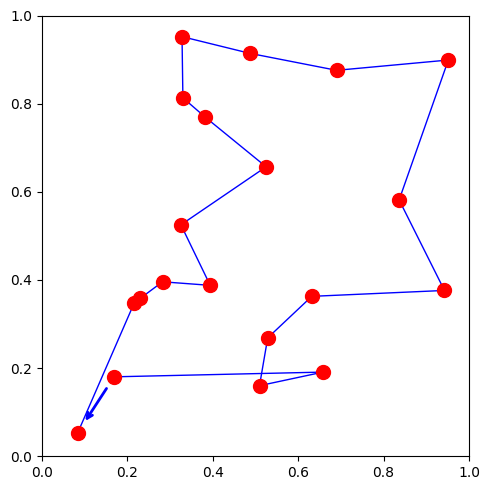

In [ ]:
points = sample_points(n)
tour = greedy_distance_heuristic(points)
plot_points_with_edges(points, tour)

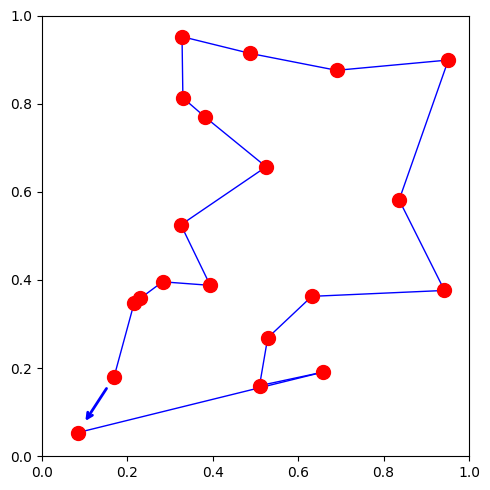

In [ ]:
plot_points_with_edges(points, two_opt_tour_step(points, tour)[0])

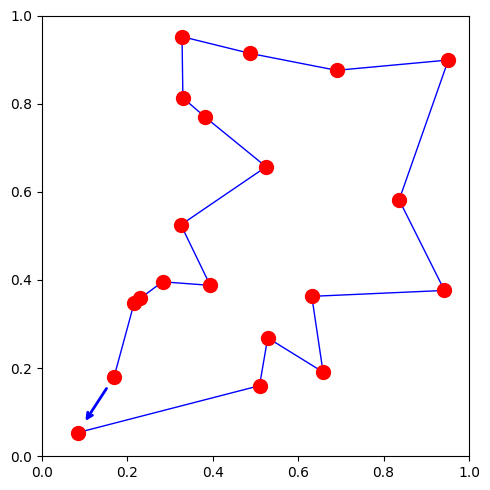

In [ ]:
plot_points_with_edges(points, two_opt_heuristic(points, tour))

### Christofides Heuristic

Now, let's recall the **Christofides heuristic**. We will use the `networkx` implementation to construct Christofides tours.

In [ ]:
def to_full_nx_graph(points):
    """
    convert 2D point coordinates to a fully-connected NetworkX graph with Euclidean edge weights.
    """
    g = nx.Graph()
    g.add_nodes_from(range(len(points)))

    weights = distance_matrix(points).cpu().numpy()
    g.add_edges_from(
        [(i, j, {'weight': weights[i,j]})
         for i in range(len(points))
         for j in range(i)]
    )
    return g

def christofides(points):
    """
    compute Christofides TSP approximation.
    """
    return to_edges(nx.algorithms.approximation.christofides(to_full_nx_graph(points)))

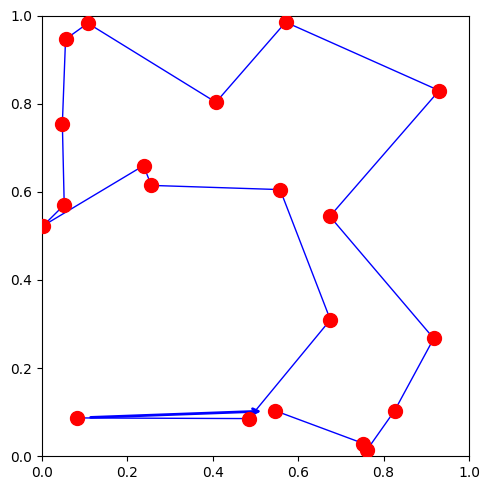

In [ ]:
points = sample_points(n)
chr_edges = christofides(points)
plot_points_with_edges(points, chr_edges)

While Christofides gives better results than greedy, we can further improve it with **2-opt optimization**. Let's implement a single iteration:

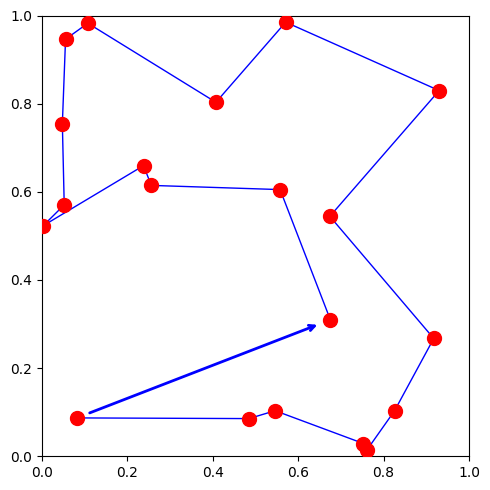

In [ ]:
plot_points_with_edges(points, two_opt_tour_step(points, christofides(points))[0])

And with full 2-opt optimization:

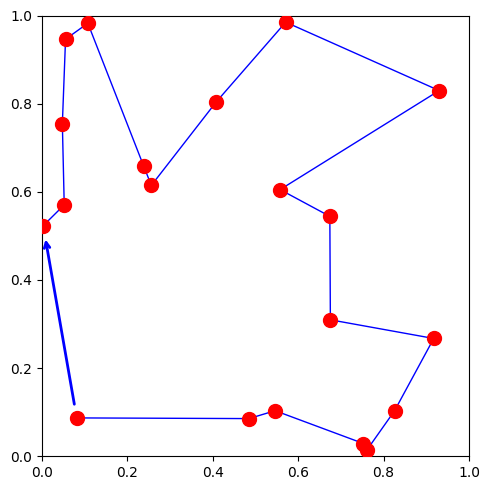

In [ ]:
plot_points_with_edges(points, two_opt_heuristic(points, christofides(points)))

Let's write simple code that evaluate the heuristics

In [ ]:
def mean_score(
    algorithm: Callable[[torch.Tensor], List[List[int]]],
    n_nodes: int,
    n_samples: int,
) -> float:
    """
    evaluates the mean tour length produced by a TSP algorithm over multiple runs.
    """
    total_score = 0.0
    for _ in tqdm.tqdm(range(n_samples), desc="Evaluating algorithm"):
        points = torch.rand((n_nodes, 2))

        tour_edges = algorithm(points)
        total_score += edges_score(points, tour_edges) / n_samples

    return total_score


In [ ]:
mean_score(greedy_distance_heuristic, n_nodes=20, n_samples=1000)

Evaluating algorithm: 100%|██████████| 1000/1000 [00:00<00:00, 1432.22it/s]


4.4781405120563615

In [ ]:
mean_score(christofides, n_nodes=20, n_samples=1000)

Evaluating algorithm: 100%|██████████| 1000/1000 [00:02<00:00, 356.52it/s]


4.156452996168337

In [ ]:
mean_score(greedy_with_two_opt, n_nodes=20, n_samples=1000)

Evaluating algorithm: 100%|██████████| 1000/1000 [00:13<00:00, 76.03it/s]


3.9567618946865184

### algorithmic heuristic

Now, let's try to build our own heuristic for this problem using only the Python standard library (+torch). We will evaluate it on 20 and 1000 nodes.
In short, our goal is to beat Christofides both in execution time and score (both are evaluated with the `mean_score` function).

during the implementation this link was very useful: https://www2.seas.gwu.edu/~simhaweb/champalg/tsp/tsp.html

In [ ]:
def heuristic(points: torch.Tensor) -> list[tuple[int, int]]:
    """
    constructs a TSP tour using an adaptive multi-start Nearest Neighbor strategy
    """
    n = points.shape[0]

    best_tour_edges = None
    best_length = float('inf')

    if n <= 50:
        num_starts = 1
    else:
        num_starts = min(n, 185)

    starts = torch.randperm(n)[:num_starts]

    for start_node_idx in starts:
        initial_edges = greedy_distance_heuristic(points, starting_node=start_node_idx.item())

        refined_edges = two_opt_heuristic(points, initial_edges)

        current_length = edges_score(points, refined_edges)

        if current_length < best_length:
            best_length = current_length
            best_tour_edges = refined_edges

    return best_tour_edges

**Target for this part was to beat Christofides (in some of tests)**

In [ ]:
mean_score(christofides, n_nodes=20, n_samples=1000)

Evaluating algorithm: 100%|██████████| 1000/1000 [00:02<00:00, 357.50it/s]


4.172457698385573

In [ ]:
mean_score(heuristic, n_nodes=20, n_samples=1000)

Evaluating algorithm: 100%|██████████| 1000/1000 [00:13<00:00, 72.79it/s]


3.9255816980975675

In [ ]:
mean_score(christofides, n_nodes=800, n_samples=10)

Evaluating algorithm: 100%|██████████| 10/10 [04:28<00:00, 26.88s/it]


23.492931659812953

In [ ]:
mean_score(heuristic, n_nodes=800, n_samples=10)

Evaluating algorithm: 100%|██████████| 10/10 [03:50<00:00, 23.03s/it]


24.64960184233351

## Part 2. Greedy heurstic with GNN

### Heatmap Model Approach

In this part, we will:
1. Train a model to predict edge probabilities (likelihood of appearing in optimal tours)
2. Use the probability matrix to construct tours via greedy heuristic

**Training Setup**:
- Dataset: 100,000 optimal tours (20-node instances from same distribution)
- Goal: Learn probability matrix P where P[i,j] = P(edge (i,j) ∈ optimal tour)

Let's first visualize some example optimal tours:



For the training, we will use optimal tours for 100k samples of size 20 from the same distribution. Let's see some optimal tour. (Link: https://drive.google.com/file/d/1eZfXPHiorsfEH3223xloulprHla7J-pg/view?usp=share_link)

In [ ]:
train_samples_data_path = "./data_tsp/samples_20.npy"
train_tours_data_path = "./data_tsp/optim_20.npy"

X = torch.tensor(np.load(train_samples_data_path), dtype=torch.float32, requires_grad=False)
Y = torch.tensor(np.load(train_tours_data_path), requires_grad=False)
Y = torch.cat([Y, Y[:, :1]], dim=1)
X.shape, Y.shape

(torch.Size([100000, 20, 2]), torch.Size([100000, 21]))

In [ ]:
mean_optimal_score = sum(edges_score(X[idx], to_edges(Y[idx])) for idx in tqdm.tqdm(range(X.shape[0]))) / X.shape[0]
print("Mean opt score for 20 nodes is ", mean_optimal_score)

100%|██████████| 100000/100000 [01:12<00:00, 1379.48it/s]

Mean opt score for 20 nodes is  3.830331205605602


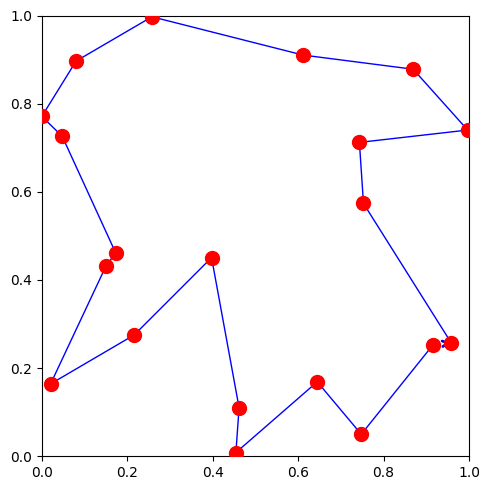

In [ ]:
idx = 0
plot_points_with_edges(X[idx], to_edges(Y[idx]))

### Model Definition

now we use a GNN and apply it to node and edge features, and then for each edge we'll predict the probability of occurrence of this edge in the optimal tour.

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.4 MB/s eta 0:00:00


In [ ]:
import torch
from torch_geometric.data import Data, Batch

def vectorize(points: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    convert point coordinates to graph representation for GNN processing.
    """
    n = points.shape[0]
    node_fts = points.clone().detach()
    dist = distance_matrix(points) + 2. * torch.eye(n, device=points.device)
    edge_index = torch.nonzero(dist).T
    edge_fts = dist[edge_index[0], edge_index[1]][:, None]
    return node_fts, edge_fts, edge_index


def tour_to_pointers(tour_edges: torch.Tensor, n_nodes: int) -> torch.Tensor:
    """
    convert circular tour to pointer representation (next-node mapping).
    """
    pointers = torch.zeros(n_nodes, dtype=torch.long)
    for edge in tour_edges:
        pointers[edge[0]] = edge[1]
    return pointers


def sample_labelled_batch(
    X: torch.Tensor,
    Y: torch.Tensor,
    batch_size: int
) -> Batch:
    data_list = []
    n_nodes = X.shape[1]
    indices = torch.randperm(X.shape[0])[:batch_size]
    for idx in indices:
        pointers = tour_to_pointers(Y[idx], n_nodes)
        node_fts, edge_fts, edge_index = vectorize(X[idx])
        data_list.append(Data(
            node_fts=node_fts,
            edge_fts=edge_fts,
            edge_index=edge_index,
            y=pointers,
            points=X[idx],
            tour=Y[idx]
        ))
    return Batch.from_data_list(data_list)

In [ ]:
import torch.nn as nn

In [ ]:
class HeatmapModel(torch.nn.Module):
    def __init__(self, node_dim=2, edge_dim=1, hidden_dim=128):
        super().__init__()
        self.node_encoder = nn.Sequential(
            nn.Linear(node_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.edge_encoder = nn.Sequential(
            nn.Linear(edge_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.edge_decoder = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, node_fts, edge_fts, edge_index):
        node_emb = self.node_encoder(node_fts)
        edge_emb = self.edge_encoder(edge_fts)

        src_nodes = node_emb[edge_index[0]]
        dst_nodes = node_emb[edge_index[1]]

        combined = torch.cat([src_nodes, dst_nodes, edge_emb], dim=-1)

        logits = self.edge_decoder(combined)
        return logits

how to evaluate:

1. **edge accuracy**: compute prediction accuracy for optimal edges  
2. **tour construction**: build tours from probabilities and evaluate their cost  

We choose the second option (greedy construction) because it uses all labeled data for training and directly optimizes for tour quality   

In [ ]:
def wrap_heatmap_model_greedy_heuristic(
    model: torch.nn.Module
) -> Callable[[torch.Tensor], List[int]]:
    def f(points: torch.Tensor) -> List[int]:
        model.eval()
        with torch.no_grad():
            n_points = points.shape[0]
            node_fts, edge_fts, edge_index = vectorize(points)

            edge_logits = model(node_fts, edge_fts, edge_index)

            #heatmap matrix from edge logits
            heatmap = torch.zeros(n_points, n_points, device=points.device)
            heatmap[edge_index[0], edge_index[1]] = edge_logits.squeeze()

            #negative heatmap as cost
            greedy_tour_edges = greedy_cost_heuristic(cost=-heatmap)

            refined_tour_edges = two_opt_heuristic(points, greedy_tour_edges)

            return refined_tour_edges
    return f

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HeatmapModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

X = torch.tensor(np.load(train_samples_data_path), dtype=torch.float32, requires_grad=False).to(device)
Y = torch.tensor(np.load(train_tours_data_path), requires_grad=False).to(device)

if Y.shape[1] == X.shape[1]:
    Y = torch.cat([Y, Y[:, :1]], dim=1)

n_samples = X.shape[0]
n_nodes = X.shape[1]

model.train()
num_epochs = 50
batch_size = 64

print(f"Training HeatmapModel for {num_epochs} epochs with batch size {batch_size} on {device}")

for epoch in range(num_epochs):
    total_loss = 0
    batch_count = 0

    perm = torch.randperm(n_samples)

    for batch_start in tqdm.tqdm(
        range(0, n_samples, batch_size),
        desc=f"Epoch {epoch+1}/{num_epochs}",
        leave=False
    ):
        optimizer.zero_grad()

        batch_indices = perm[batch_start:batch_start + batch_size]
        current_batch_size = len(batch_indices)

        data_list = []
        batched_optimal_adj = torch.zeros(current_batch_size, n_nodes, n_nodes, dtype=torch.bool, device=device)

        for idx_in_batch, original_idx in enumerate(batch_indices):
            current_points = X[original_idx]
            current_optimal_tour = Y[original_idx]

            node_fts, edge_fts, edge_index = vectorize(current_points)

            data_list.append(Data(
                node_fts=node_fts,
                edge_fts=edge_fts,
                edge_index=edge_index,
            ))

            #adjacency matrix for this graph
            for i in range(n_nodes):
                u, v = current_optimal_tour[i].item(), current_optimal_tour[i+1].item()
                batched_optimal_adj[idx_in_batch, u, v] = True
                batched_optimal_adj[idx_in_batch, v, u] = True

        batch_data = Batch.from_data_list(data_list).to(device)

        #forward pass
        logits = model(batch_data.node_fts, batch_data.edge_fts, batch_data.edge_index)

        #vectorized target
        targets = torch.zeros_like(logits, dtype=torch.float32)
        num_edges_per_graph_in_vectorize = n_nodes * n_nodes

        batch_edge_offset = 0
        for i in range(current_batch_size):
            graph_edge_indices_in_batch_src = batch_data.edge_index[0, batch_edge_offset : batch_edge_offset + num_edges_per_graph_in_vectorize]
            graph_edge_indices_in_batch_dst = batch_data.edge_index[1, batch_edge_offset : batch_edge_offset + num_edges_per_graph_in_vectorize]

            local_src = graph_edge_indices_in_batch_src - (i * n_nodes)
            local_dst = graph_edge_indices_in_batch_dst - (i * n_nodes)

            #find optimal edges
            is_optimal_edge = batched_optimal_adj[i, local_src, local_dst]

            targets[batch_edge_offset : batch_edge_offset + num_edges_per_graph_in_vectorize][is_optimal_edge.squeeze()] = 1.0

            batch_edge_offset += num_edges_per_graph_in_vectorize

        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        batch_count += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/batch_count:.4f}')

model.eval()


Training HeatmapModel for 50 epochs with batch size 64 on cpu


Epoch 1/50, Loss: 0.1713


Epoch 5/50, Loss: 0.1643


Epoch 10/50, Loss: 0.1641


Epoch 15/50, Loss: 0.1640


...

Epoch 35/50, Loss: 0.1637


Epoch 40/50, Loss: 0.1637


Epoch 45/50, Loss: 0.1637


Epoch 50/50, Loss: 0.1636


HeatmapModel(
  (node_encoder): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (edge_encoder): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (edge_decoder): Sequential(
    (0): Linear(in_features=384, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [ ]:
mean_score(wrap_heatmap_model_greedy_heuristic(model), n_nodes=20, n_samples=1000)

Evaluating algorithm: 100%|██████████| 1000/1000 [00:11<00:00, 90.69it/s]


3.9105312846795157

## Part 3. Autoregressive model

we will train a model to add new edges to a partially constructed tour. The model will learn to predict the next optimal node to connect to the current border node of a partial solution.

### setup
- we have a **partial solution** represented as a chain of edges
- **starting node** and **border node** are the leaves of this chain
- The model receives:
  - points
  - distances between them
  - masks of available nodes
  - masks identifying the starting and border nodes
- model outputs logits of shape `(num_nodes,)` representing probabilities for edges from the border node to each candidate node

### Key Reference
[Neural Combinatorial Optimization with Heavy Decoder: Toward Large Scale Generalization](https://arxiv.org/abs/2310.07985)


### Architecture Components
1. **Graph Encoder**:
   - simple 1-layer GNN
   - encodes the full graph structure (without partial tour information)

2. **Processor Network**:
   - GNN (can be multi-layer or single-layer applied iteratively)
   - takes encoder output and node masks as input
   - predicts the next node to add to the partial tour

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class ARModel(torch.nn.Module):
    """autoregressive model for TSP that predicts the next node to add to a partial tour.
    """

    def __init__(self, node_feat_dim=2, edge_feat_dim=2, hidden_dim=128, num_layers=3):
        """Initializes the AR model components with GNN layers for graph encoding."""
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.node_encoder = nn.Sequential(
            nn.Linear(node_feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        #for relative positions (dx, dy)
        self.edge_encoder = nn.Sequential(
            nn.Linear(edge_feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.conv_layers = nn.ModuleList()
        for _ in range(num_layers):
            self.conv_layers.append(GCNConv(hidden_dim, hidden_dim))
            self.conv_layers.append(nn.Linear(hidden_dim * 2, hidden_dim))

        self.attention = nn.MultiheadAttention(hidden_dim, num_heads=4, batch_first=True)

        #prediction head
        self.predictor = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

        self.layer_norm1 = nn.LayerNorm(hidden_dim)
        self.layer_norm_output = nn.LayerNorm(hidden_dim)


    def forward(
        self,
        node_fts: torch.Tensor,
        edge_fts: torch.Tensor,
        edge_index: torch.Tensor,
        is_used_node: torch.Tensor,
        is_border_node: torch.Tensor,
        is_starting_node: torch.Tensor
    ) -> torch.Tensor:
        num_nodes = node_fts.shape[0]
        device = node_fts.device

        x = self.node_encoder(node_fts) #(num_nodes, hidden_dim)

        encoded_edge_fts = self.edge_encoder(edge_fts) #(num_edges, hidden_dim)

        edge_attr_map = torch.zeros(num_nodes, num_nodes, self.hidden_dim, device=device)
        for i in range(edge_index.shape[1]):
            u, v = edge_index[0, i], edge_index[1, i]
            edge_attr_map[u, v] = encoded_edge_fts[i]

        for i in range(self.num_layers):
            x_gcn = self.conv_layers[i*2](x, edge_index)
            x_gcn = F.relu(x_gcn)
            x_gcn = self.layer_norm1(x_gcn)

            #sum features of edges starting from u
            aggregated_edge_from = edge_attr_map[range(num_nodes), :, :].sum(dim=1)
            aggregated_edge_to = edge_attr_map[:, range(num_nodes), :].sum(dim=0)

            combined_features_for_next_layer = torch.cat([x_gcn, aggregated_edge_from + aggregated_edge_to], dim=-1)
            x = self.conv_layers[i*2 + 1](combined_features_for_next_layer)
            x = F.relu(x)
            x = self.layer_norm1(x)


        #border node embedding
        border_idx = torch.argmax(is_border_node.squeeze()).item()
        border_embedding = x[border_idx].unsqueeze(0).unsqueeze(0)

        attn_output, _ = self.attention(
            query=border_embedding,
            key=x.unsqueeze(0),
            value=x.unsqueeze(0)
        )
        attn_output = attn_output.squeeze(0)
        attended_border_context = attn_output.expand(num_nodes, -1)
        combined_for_prediction = torch.cat([x, attended_border_context], dim=-1)

        logits = self.predictor(combined_for_prediction).squeeze(-1)

        #used nodes
        mask = is_used_node.squeeze().bool()
        logits = logits.masked_fill(mask, -torch.inf)

        return logits

In [ ]:
def wrap_autoregressive_model_heuristic(
    model: torch.nn.Module
) -> Callable[[torch.Tensor], List[int]]:
    def f(points: torch.Tensor) -> List[int]:
        n_nodes = points.shape[0]
        device = next(model.parameters()).device

        is_used_node = torch.zeros(n_nodes, 1, device=device)
        is_border_node = torch.zeros(n_nodes, 1, device=device)
        is_starting_node = torch.zeros(n_nodes, 1, device=device)

        #random starting node
        start_node = torch.randint(0, n_nodes, (1,)).item()
        is_used_node[start_node] = 1
        is_border_node[start_node] = 1
        is_starting_node[start_node] = 1

        tour = [start_node]

        edge_index_list = []
        edge_features_list = []
        for i in range(n_nodes):
            for j in range(n_nodes):
                if i != j:
                    edge_index_list.append([i, j])
                    rel_pos = points[j] - points[i]
                    edge_features_list.append([rel_pos[0].item(), rel_pos[1].item()])

        edge_index = torch.tensor(edge_index_list, device=device).t().contiguous()
        edge_features = torch.tensor(edge_features_list, device=device)

        #build tour
        for _ in range(n_nodes - 1):
            with torch.no_grad():
                next_node_logits = model(
                    points.to(device),
                    edge_features,
                    edge_index,
                    is_used_node,
                    is_border_node,
                    is_starting_node
                )

                #convert to probabilities and sample
                next_node_probs = F.softmax(next_node_logits, dim=0)
                next_node = torch.multinomial(next_node_probs, 1).item()

                is_used_node[next_node] = 1
                is_border_node.zero_()
                is_border_node[next_node] = 1

                tour.append(next_node)

        #complete the cycle
        tour.append(start_node)

        return to_edges(tour)
    return f


def wrap_best_of_n_sampling_from_model(model: torch.nn.Module, n_samples: int) -> Callable[[torch.Tensor], List[int]]:
    def f(points: torch.Tensor) -> List[int]:
        # <YOUR CODE HERE>
        best_tour = None
        best_score = float('inf')

        for _ in range(n_samples):
            tour_edges = wrap_autoregressive_model_heuristic(model)(points)
            tour_score = edges_score(points, tour_edges)

            if tour_score < best_score:
                best_score = tour_score
                best_tour = tour_edges

        return best_tour
    return f

In [ ]:
import torch
import torch.nn.functional as F
from torch.distributions import Categorical
import numpy as np

def compute_tour_length(points, tour_edges):
    return sum(distance(points[i], points[j]) for i, j in tour_edges)

moving_avg_baseline = None
alpha = 0.99 #for the moving average

def reinforce_train_step(model, points, optimizer, device):
    global moving_avg_baseline

    model.train()
    n_nodes = points.shape[0]

    #masks
    is_used_node = torch.zeros(n_nodes, 1, device=device)
    is_border_node = torch.zeros(n_nodes, 1, device=device)
    is_starting_node = torch.zeros(n_nodes, 1, device=device)

    #random starting node
    start_node = torch.randint(0, n_nodes, (1,)).item()
    is_used_node[start_node] = 1
    is_border_node[start_node] = 1
    is_starting_node[start_node] = 1

    #complete graph
    edge_index = []
    edge_features = []
    for i in range(n_nodes):
        for j in range(n_nodes):
            if i != j:
                edge_index.append([i, j])
                rel_pos = points[j] - points[i]
                edge_features.append([rel_pos[0].item(), rel_pos[1].item()])

    edge_index = torch.tensor(edge_index, device=device).t().contiguous()
    edge_features = torch.tensor(edge_features, device=device)

    saved_log_probs = []
    actions = []

    current_tour = [start_node]
    current_border = start_node

    for step in range(n_nodes - 1):
        node_logits = model(
            points.to(device),
            edge_features,
            edge_index,
            is_used_node,
            is_border_node,
            is_starting_node
        )

        node_probs = F.softmax(node_logits, dim=0)
        dist = Categorical(node_probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)

        saved_log_probs.append(log_prob)
        actions.append(action.item())

        next_node = action.item()
        is_used_node[next_node] = 1
        is_border_node = torch.zeros(n_nodes, 1, device=device)
        is_border_node[next_node] = 1

        current_tour.append(next_node)
        current_border = next_node

    current_tour.append(start_node)
    tour_edges = to_edges(current_tour)

    with torch.no_grad():
        tour_length = compute_tour_length(points, tour_edges)
        reward = -tour_length  #to minimize length

    if moving_avg_baseline is None:
        moving_avg_baseline = reward
    else:
        moving_avg_baseline = alpha * moving_avg_baseline + (1 - alpha) * reward

    policy_loss = []
    for log_prob in saved_log_probs:
        policy_loss.append(-log_prob * (reward - moving_avg_baseline))

    policy_loss = torch.stack(policy_loss).sum()

    #optimization step
    optimizer.zero_grad()
    policy_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    return policy_loss.item(), tour_length

def train_autoregressive_model(n_epochs=1000, batch_size=128, n_nodes=20, lr=1e-3):
    global moving_avg_baseline
    moving_avg_baseline = None

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    model = ARModel(edge_feat_dim=2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.8)

    #history
    train_losses = []
    train_lengths = []

    print("Starting training...")

    for epoch in range(n_epochs):
        model.train()
        epoch_losses = []
        epoch_lengths = []

        for batch_idx in range(batch_size):
            #random TSP instance
            points = sample_points(n_nodes)

            #step
            loss, tour_length = reinforce_train_step(model, points, optimizer, device)

            epoch_losses.append(loss)
            epoch_lengths.append(tour_length)

        #update lr
        scheduler.step()

        avg_loss = np.mean(epoch_losses)
        avg_length = np.mean(epoch_lengths)

        train_losses.append(avg_loss)
        train_lengths.append(avg_length)

        if epoch % 100 == 0 or epoch < 15:
            current_lr = scheduler.get_last_lr()[0]
            print(f"Epoch {epoch:4d}/{n_epochs} | "
                  f"Loss: {avg_loss:8.2f} | "
                  f"Avg Tour Length: {avg_length:6.3f} | "
                  f"LR: {current_lr:.2e}")

    return model

trained_model = train_autoregressive_model(
    n_epochs=250,
    batch_size=128,
    n_nodes=20,
    lr=5e-4
)


Using device: cpu
Starting training...
Epoch    0/250 | Loss:   -13.18 | Avg Tour Length: 10.308 | LR: 5.00e-04
Epoch    1/250 | Loss:    -1.31 | Avg Tour Length: 10.239 | LR: 5.00e-04
Epoch    2/250 | Loss:    -4.24 | Avg Tour Length: 10.464 | LR: 5.00e-04
Epoch    3/250 | Loss:    -1.77 | Avg Tour Length: 10.411 | LR: 5.00e-04
Epoch    4/250 | Loss:     7.15 | Avg Tour Length: 10.196 | LR: 5.00e-04
Epoch    5/250 | Loss:    -7.67 | Avg Tour Length: 10.612 | LR: 5.00e-04
Epoch    6/250 | Loss:     0.28 | Avg Tour Length: 10.437 | LR: 5.00e-04
Epoch    7/250 | Loss:     2.27 | Avg Tour Length: 10.371 | LR: 5.00e-04
Epoch    8/250 | Loss:    -2.66 | Avg Tour Length: 10.515 | LR: 5.00e-04
Epoch    9/250 | Loss:     1.70 | Avg Tour Length: 10.473 | LR: 5.00e-04
Epoch   10/250 | Loss:     1.82 | Avg Tour Length: 10.337 | LR: 5.00e-04
Epoch   11/250 | Loss:    -2.06 | Avg Tour Length: 10.496 | LR: 5.00e-04
Epoch   12/250 | Loss:     0.53 | Avg Tour Length: 10.428 | LR: 5.00e-04
Epoch   13/2

In [ ]:
mean_score(wrap_best_of_n_sampling_from_model(trained_model, n_samples=1), n_nodes=20, n_samples=1000)

Evaluating algorithm: 100%|██████████| 1000/1000 [02:10<00:00,  7.65it/s]


9.556370021316317